---
# PRCP- 1006 - HOME LOAN DEFAULT PREDICTION 
---

### Project By
 ANIKET RAMNIWAS CHAUHAN 
 
### Tools Used
 Python, Pandas, NumPy, Scikit-Learn, Matplotlib

----

---
## 1] Problem Statement
---

The banking sector faces significant challenges in identifying customers who are likely to default on their loans. Loan defaults can result in substantial financial losses and increased credit risk for financial institutions. Therefore, it is essential to analyze customer information, credit history, and repayment behavior to identify potential defaulters before loan approval.

The objective of this project is to analyze customer loan data and develop a predictive model that can accurately identify customers who are likely to default on their loans. The insights generated from this analysis can help financial institutions improve lending decisions and reduce financial risk.

---


----
## 2] Project Objective
---
1. Perform exploratory data analysis on customer loan application data.

2. Identify patterns and factors associated with loan default.

3. Handle missing values and prepare the dataset for machine learning.

4. Perform feature engineering using multiple banking datasets.

5. Build and compare multiple machine learning models.

6. Select the best performing model for production deployment.

7. Provide business recommendations to improve loan approval decisions and reduce credit risk.

---

---
## 3] Dataset Description
---

The project utilizes multiple datasets from the Home Credit loan portfolio.

1. application_train.csv

   * Main application dataset containing customer demographic and financial information.
   * Includes the target variable where:

     * 1 = Defaulter
     * 0 = Non-Defaulter

2. bureau.csv

   * Contains historical credit information from external financial institutions.

3. previous_application.csv

   * Contains details of customers' previous loan applications.

4. installments_payments.csv

   * Contains repayment history and installment payment information.

Feature engineering was performed by aggregating customer-level information from bureau, previous_application, and installments_payments datasets using SK_ID_CURR as the primary key.

---

----
## 4] Import Libraries

---

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

---
## 5] Dataset Loading And Initial Inspection 
---
Objective

Load the datasets and understand their structure.

Analysis

The datasets were imported successfully using Pandas. Initial inspection was performed using:

* Shape
* Head
* Info
* Describe

This helped identify:

* Number of records
* Number of features
* Data types
* Missing values
* Distribution of numerical variables

Insight

The dataset contains a large number of customer records and sufficient information for predictive modeling.

---

In [2]:
app = pd.read_csv("application_train.csv")

In [3]:
files = [
    "bureau.csv",
    "bureau_balance.csv",
    "POS_CASH_balance.csv",
    "credit_card_balance.csv",
    "previous_application.csv",
    "installments_payments.csv"]

In [4]:
app.shape

(307511, 122)

In [5]:
for file in files:
    df = pd.read_csv(file)
    print(file, df.shape)

bureau.csv (1716428, 17)
bureau_balance.csv (27299925, 3)
POS_CASH_balance.csv (10001358, 8)
credit_card_balance.csv (3840312, 23)
previous_application.csv (1670214, 37)
installments_payments.csv (13605401, 8)


In [6]:
app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [8]:
app.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


---
## 6] Missing Value Analysis
---

In [9]:
missing = (app.isnull().sum()/len(app))*100

missing = missing.sort_values(ascending=False)
print(missing.head(20))

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64


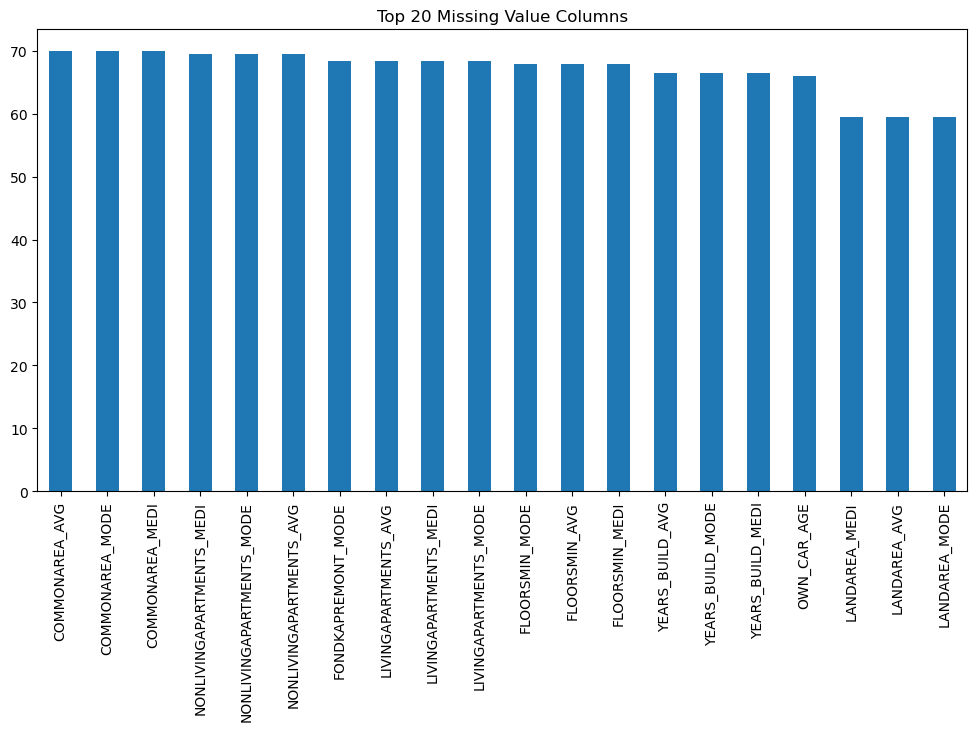

In [10]:
plt.figure(figsize=(12,6))
missing.head(20).plot(kind='bar')
plt.title("Top 20 Missing Value Columns")
plt.show()

### Insight

The dataset contained a significant number of missing values across multiple features. Some variables such as COMMONAREA_AVG, LIVINGAPARTMENTS_AVG, FLOORSMIN_AVG, and YEARS_BUILD_AVG had more than 60% missing values.

To preserve maximum information from the dataset, missing values in numerical features were replaced using the median value, while missing values in categorical features were replaced using the mode. This approach helped maintain the dataset size and prevented information loss that could occur due to row deletion.
_____

---
## 7] Target Variable Analysis
---

In [11]:
app['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

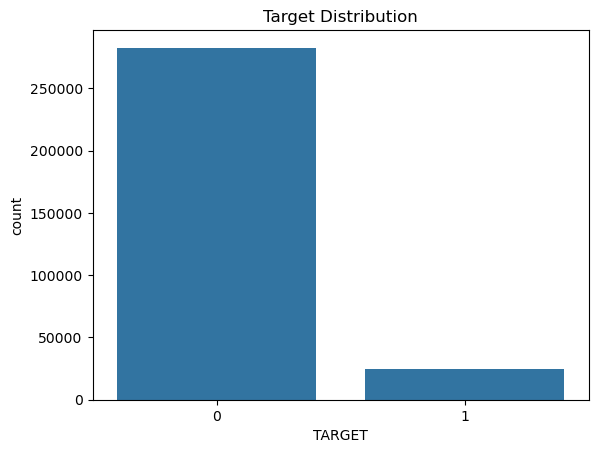

In [12]:
sns.countplot(x='TARGET',data=app)
plt.title("Target Distribution")
plt.show()

### Insight
The dataset is highly imbalanced. About 92% of customers are non-defaulters, while only 8% are defaulters.
In target variable Out of 307,511 customers, 282,686 customers (92%) belong to the non-defaulter category, while only 24,825 customers (8%) belong to the defaulter category.
____

---
## 8] Gender Analysis
---

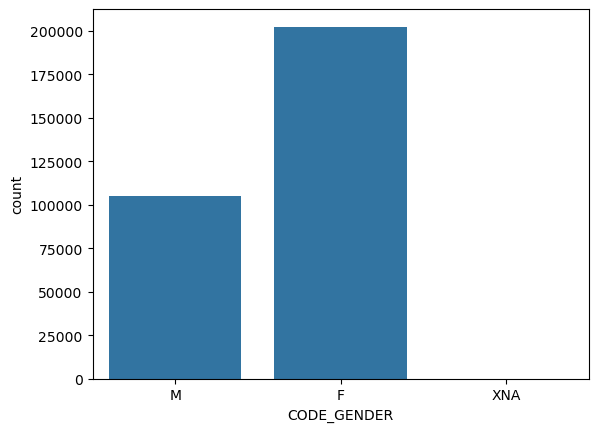

In [13]:
sns.countplot(x='CODE_GENDER',data=app)
plt.show()

### Insight
Female applicants are higher than male applicants in the dataset, indicating that a large portion of loan applications come from female customers.
_____

---
## 9] Gender-Wise Distribution Of Loan Default Analysis
---

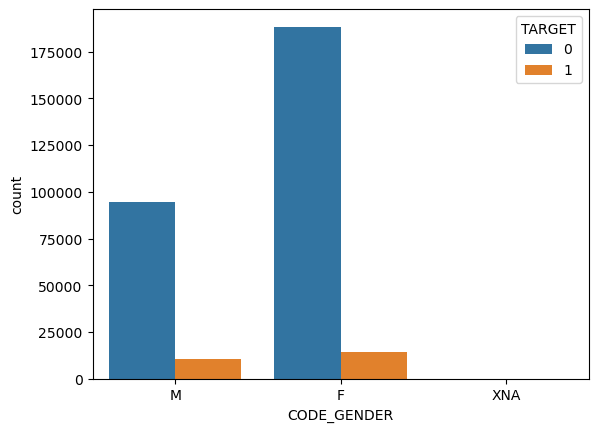

In [14]:
sns.countplot(x='CODE_GENDER',hue='TARGET',data=app)
plt.show()

### Insight
Both male and female applicants contain defaulters and non-defaulters. Gender alone is not sufficient to determine loan default.
______

---
## 10] Distribution Of Applicant Income
---

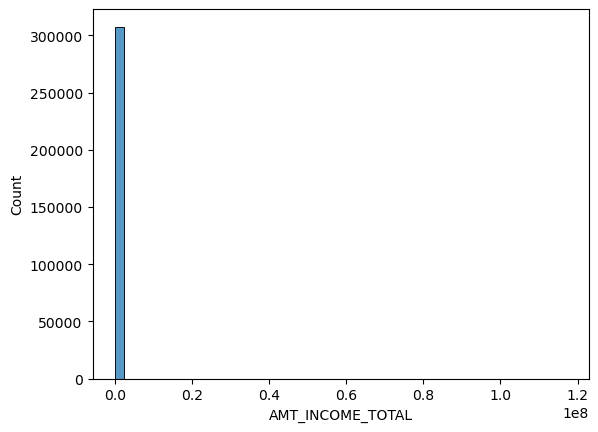

In [15]:
sns.histplot(app['AMT_INCOME_TOTAL'],bins=50)
plt.show()

### Insight
Most customers belong to the low and middle-income groups, while only a few customers have very high incomes.
_____

---
## 11] Income Vs Loan Default Analysis
---

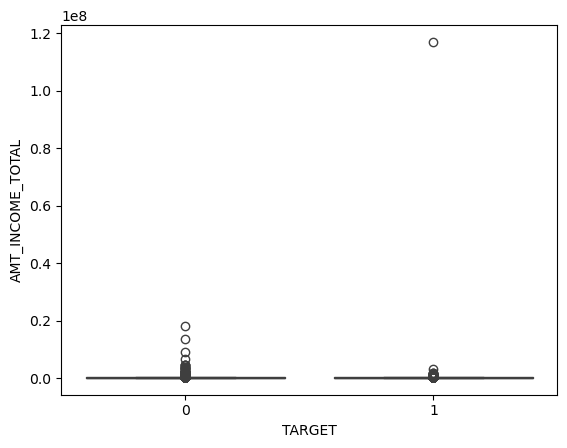

In [16]:
sns.boxplot(
    x='TARGET',
    y='AMT_INCOME_TOTAL',
    data=app)
plt.show()

### Insight
Income level appears to influence loan repayment ability. Customers with lower income may have a higher risk of default.
______

---
## 12] Age Analysis
---

In [17]:
app['AGE'] = abs(app['DAYS_BIRTH'])/365

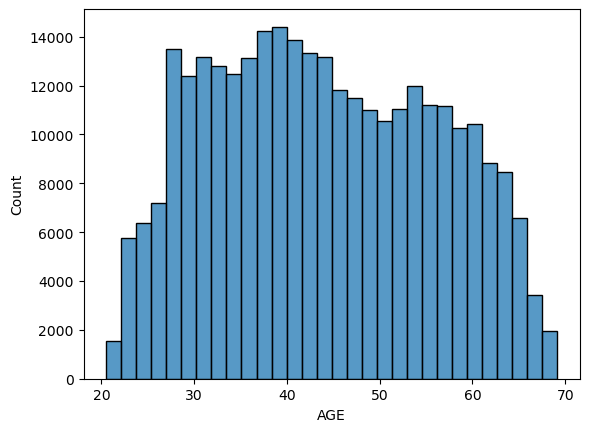

In [18]:
sns.histplot(app['AGE'],bins=30)
plt.show()

### Insight
Most loan applicants belong to the working-age population, indicating that economically active individuals apply for loans more frequently.
____

--- 
## 13] Age Vs Loan Default Analysis
---

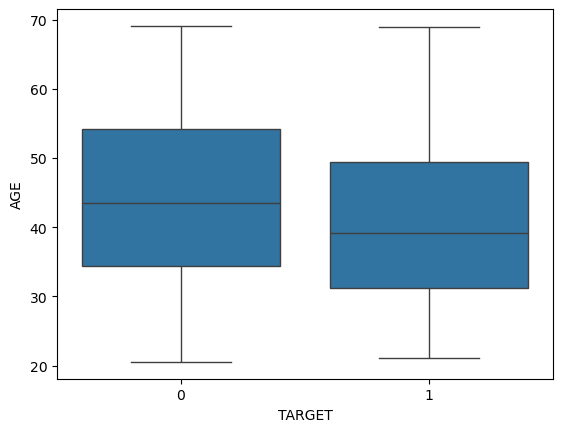

In [19]:
sns.boxplot(x='TARGET',y='AGE',data=app)
plt.show()

### Insight
Loan repayment behavior varies across age groups. Age can be a useful feature for predicting loan default.
____

----
## 14] Data Preprocessing
---

### Insight
The dataset contained missing values in several columns. Numerical missing values were replaced using the median, while categorical missing values were replaced using the mode to avoid data loss.
_____

In [20]:
categorical_cols = app.select_dtypes(include=['object']).columns
numerical_cols = app.select_dtypes(exclude=['object']).columns
print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 16
Numerical: 107


In [21]:
num_cols = app.select_dtypes(
    include=['int64','float64']).columns
for col in num_cols:
    app[col] = app[col].fillna(
        app[col].median())

In [22]:
cat_cols = app.select_dtypes(
    include=['object']).columns
for col in cat_cols:
    app[col] = app[col].fillna(
        app[col].mode()[0])

In [23]:
app.isnull().sum().sum()

np.int64(0)

In [24]:
cat_cols = app.select_dtypes(include=['object']).columns
print("Number of categorical columns:", len(cat_cols))
for col in cat_cols:
    print(col)

Number of categorical columns: 16
NAME_CONTRACT_TYPE
CODE_GENDER
FLAG_OWN_CAR
FLAG_OWN_REALTY
NAME_TYPE_SUITE
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
NAME_HOUSING_TYPE
OCCUPATION_TYPE
WEEKDAY_APPR_PROCESS_START
ORGANIZATION_TYPE
FONDKAPREMONT_MODE
HOUSETYPE_MODE
WALLSMATERIAL_MODE
EMERGENCYSTATE_MODE


### Insight
Categorical variables were converted into numerical format using One-Hot Encoding so that machine learning algorithms could process them effectively.
_____

In [25]:
app = pd.get_dummies(
    app,
    columns=[
        'NAME_CONTRACT_TYPE',
        'CODE_GENDER',
        'FLAG_OWN_CAR',
        'FLAG_OWN_REALTY',
        'NAME_TYPE_SUITE',
        'NAME_INCOME_TYPE',
        'NAME_EDUCATION_TYPE',
        'NAME_FAMILY_STATUS',
        'NAME_HOUSING_TYPE',
        'OCCUPATION_TYPE',
        'WEEKDAY_APPR_PROCESS_START',
        'ORGANIZATION_TYPE',
        'FONDKAPREMONT_MODE',
        'HOUSETYPE_MODE',
        'WALLSMATERIAL_MODE',
        'EMERGENCYSTATE_MODE'],
    drop_first=True)

In [26]:
app.shape

(307511, 231)

In [27]:
x = app.drop('TARGET', axis=1)
y = app['TARGET']

---
## 15] Train-Test Split
---

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

### Insight
The dataset was divided into training and testing sets using an 80:20 ratio. This allowed the model to be trained on one portion of the data and evaluated on unseen data. 
_____

---
## 16] Feature Scaling
---

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Insight
Feature scaling was performed using StandardScaler to ensure all numerical variables were on a similar scale and to improve model performance.
_____

---
## 17] Logistic Regression
---

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [33]:
lr = LogisticRegression(max_iter=1000)

In [34]:
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [35]:
y_pred_lr = lr.predict(X_test)

In [36]:
print("Accuracy:",accuracy_score(y_test,y_pred_lr))

Accuracy: 0.9194673430564363


In [37]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.56      0.01      0.02      4965

    accuracy                           0.92     61503
   macro avg       0.74      0.51      0.49     61503
weighted avg       0.89      0.92      0.88     61503



In [38]:
print(confusion_matrix(y_test,y_pred_lr))

[[56490    48]
 [ 4905    60]]


## Insight
Logistic Regression achieved high accuracy but failed to identify most defaulters due to class imbalance in the dataset.
_____

---
## 18] Balanced Logistic Regression
---

In [39]:
lr_balanced = LogisticRegression(class_weight='balanced',max_iter=1000)

In [40]:
lr_balanced.fit(X_train, y_train)
y_pred_balanced = lr_balanced.predict(X_test)

In [41]:
print("Accuracy:",accuracy_score(y_test,y_pred_balanced))

Accuracy: 0.6898037494105979


In [42]:
print(classification_report(y_test,y_pred_balanced))

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.69      0.53     61503
weighted avg       0.90      0.69      0.76     61503



In [43]:
print(confusion_matrix(y_test,y_pred_balanced))

[[39052 17486]
 [ 1592  3373]]


## Insight
Applying class balancing significantly improved recall from 1% to 68%, allowing the model to identify a much larger number of potential defaulters.
______

---
## 19] Decision Tree
---

In [44]:
from sklearn.tree import DecisionTreeClassifier

In [45]:
dt = DecisionTreeClassifier(random_state=42,class_weight='balanced')

In [46]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [47]:
y_pred_dt = dt.predict(X_test)

In [48]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.8583971513584703


In [49]:
print(confusion_matrix(y_test, y_pred_dt))

[[51976  4562]
 [ 4147   818]]


In [50]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92     56538
           1       0.15      0.16      0.16      4965

    accuracy                           0.86     61503
   macro avg       0.54      0.54      0.54     61503
weighted avg       0.86      0.86      0.86     61503



## Insight
Decision Tree captured complex patterns in the data but produced lower recall compared to Balanced Logistic Regression.
_____

---
## 20] Random Forest
---

In [51]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
rf = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced',n_jobs=-1)

In [53]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [54]:
y_pred_rf = rf.predict(X_test)

In [55]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.9192397118839731


In [56]:
print(confusion_matrix(y_test, y_pred_rf))

[[56528    10]
 [ 4957     8]]


In [57]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.44      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.68      0.50      0.48     61503
weighted avg       0.88      0.92      0.88     61503



## Insight
Random Forest achieved high accuracy but struggled to identify defaulters because of the highly imbalanced target variable.
_______

---
## 21] XGBoost
---

In [58]:
from xgboost import XGBClassifier

In [59]:
xgb = XGBClassifier(n_estimators=100,max_depth=6,learning_rate=0.1,random_state=42,eval_metric='logloss')

In [60]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [61]:
y_pred_xgb = xgb.predict(X_test)

In [62]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

Accuracy: 0.9198413085540543


### Insight

XGBoost produced strong accuracy but struggled to detect minority-class customers effectively.

---

---
## 22] XGBoost Model Performance Evaluation
---

In [63]:
print(confusion_matrix(y_test, y_pred_xgb))

[[56485    53]
 [ 4877    88]]


In [64]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.62      0.02      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.77      0.51      0.50     61503
weighted avg       0.90      0.92      0.88     61503



---
## 23] Model Comaprison
---

In [65]:
model_comparison = pd.DataFrame({'Model': ['Logistic Regression','Balanced Logistic Regression','Decision Tree','Random Forest','XGBoost'],
'Accuracy (%)': [91.95,68.98,85.84,91.92,91.98 ],
'Precision (Class 1)': [0.56,0.16,0.15,0.44,0.62],
'Recall (Class 1)': [0.01,0.68,0.16,0.00,0.02],
'F1 Score (Class 1)': [0.02,0.26,0.16,0.00,0.03]})

In [66]:
model_comparison

,Model,Accuracy (%),Precision (Class 1),Recall (Class 1),F1 Score (Class 1)
0,Logistic Regression,91.95,0.56,0.01,0.02
1,Balanced Logistic Regression,68.98,0.16,0.68,0.26
2,Decision Tree,85.84,0.15,0.16,0.16
3,Random Forest,91.92,0.44,0.00,0.00
4,XGBoost,91.98,0.62,0.02,0.03


### Insight
Although Logistic Regression, Random Forest, and XGBoost achieved high accuracy, they failed to identify defaulters effectively due to class imbalance.

Balanced Logistic Regression achieved the highest recall among the baseline models and was therefore selected for further improvement.
______

---
## 24] Bureau Dataset Feature Engineering
---

## Insight
The bureau dataset contains customers' historical credit information from external financial institutions. This information helps capture previous borrowing behavior and outstanding liabilities.
_______

In [67]:
bureau = pd.read_csv("bureau.csv")

In [68]:
bureau.shape

(1716428, 17)

In [69]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [70]:
bureau.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY'],
      dtype='object')

## Creating Bureau Features

### Total Previous Loans

In [71]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({'SK_ID_BUREAU':'count'})
bureau_agg.rename(columns={'SK_ID_BUREAU':'TOTAL_BUREAU_LOANS'},inplace=True)

### Average Credit Amount

In [72]:
credit_sum = bureau.groupby('SK_ID_CURR')['AMT_CREDIT_SUM'].mean()
bureau_agg['AVG_CREDIT_SUM'] = credit_sum

### Total Debt 

In [73]:
debt_sum = bureau.groupby('SK_ID_CURR')['AMT_CREDIT_SUM_DEBT'].sum()
bureau_agg['TOTAL_DEBT'] = debt_sum

### Maximum Previous Credit

In [74]:
max_credit = bureau.groupby('SK_ID_CURR')['AMT_CREDIT_SUM'].max()
bureau_agg['MAX_CREDIT_SUM'] = max_credit

### Active Loans

In [75]:
active_loans = bureau[bureau['CREDIT_ACTIVE']=='Active']
active_count = active_loans.groupby('SK_ID_CURR')['SK_ID_BUREAU'].count()
bureau_agg['ACTIVE_LOANS'] = active_count

### Closed Loans

In [76]:
closed_loans = bureau[bureau['CREDIT_ACTIVE']=='Closed']
closed_count = closed_loans.groupby('SK_ID_CURR')['SK_ID_BUREAU'].count()
bureau_agg['CLOSED_LOANS'] = closed_count

### Insight
Customer-level credit history features were created from the bureau dataset to summarize previous borrowing activity and debt obligations.
______

### Filling missing value 

In [77]:
bureau_agg = bureau_agg.fillna(0)

In [78]:
bureau_agg.shape

(305811, 6)

In [79]:
bureau_agg.head()

,TOTAL_BUREAU_LOANS,AVG_CREDIT_SUM,TOTAL_DEBT,MAX_CREDIT_SUM,ACTIVE_LOANS,CLOSED_LOANS
SK_ID_CURR,,,,,,
100001,7,207623.571429,596686.5,378000.0,3.0,4.0
100002,8,108131.945625,245781.0,450000.0,2.0,6.0
100003,4,254350.125000,0.0,810000.0,1.0,3.0
100004,2,94518.900000,0.0,94537.8,0.0,2.0
100005,3,219042.000000,568408.5,568800.0,2.0,1.0


## Merging Bureau Features with app

In [80]:
app_bureau = app.merge(bureau_agg,on='SK_ID_CURR',how='left') 

## Insight
The engineered bureau features were merged with the main application dataset using SK_ID_CURR, creating a richer customer profile.
______

In [81]:
app_bureau.shape

(307511, 237)

In [82]:
app_bureau[['TOTAL_BUREAU_LOANS',
            'AVG_CREDIT_SUM',
            'TOTAL_DEBT',
            'MAX_CREDIT_SUM',
            'ACTIVE_LOANS',
            'CLOSED_LOANS']].head()

,TOTAL_BUREAU_LOANS,AVG_CREDIT_SUM,TOTAL_DEBT,MAX_CREDIT_SUM,ACTIVE_LOANS,CLOSED_LOANS
0,8.0,108131.945625,245781.0,450000.0,2.0,6.0
1,4.0,254350.125000,0.0,810000.0,1.0,3.0
2,2.0,94518.900000,0.0,94537.8,0.0,2.0
3,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,146250.000000,0.0,146250.0,0.0,1.0


### Filling missing values, Some customers won't have bureau records.

In [83]:
app_bureau[
    [
        'TOTAL_BUREAU_LOANS',
        'AVG_CREDIT_SUM',
        'TOTAL_DEBT',
        'MAX_CREDIT_SUM',
        'ACTIVE_LOANS',
        'CLOSED_LOANS']] = app_bureau[[
        'TOTAL_BUREAU_LOANS',
        'AVG_CREDIT_SUM',
        'TOTAL_DEBT',
        'MAX_CREDIT_SUM',
        'ACTIVE_LOANS',
        'CLOSED_LOANS']].fillna(0)

In [84]:
app_bureau.shape

(307511, 237)

### Insight
The addition of bureau features provided historical credit information that will help improve the model's understanding of customer risk.
______

---
## 25] Previous Application Feature Engineering
---

In [85]:
previous = pd.read_csv("previous_application.csv")

In [86]:
previous.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
       'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE',
       'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE',
       'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE',
       'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE',
       'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
       'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION',
       'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
       'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL'],
      dtype='object')

### Total Previous Applications 

In [87]:
prev_agg = previous.groupby('SK_ID_CURR').agg({'SK_ID_PREV':'count'})
prev_agg.rename(columns={'SK_ID_PREV':'TOTAL_PREV_APPS'},inplace=True)

### Approved Applications

In [88]:
approved = previous[previous['NAME_CONTRACT_STATUS']=='Approved']
approved_count = approved.groupby('SK_ID_CURR')['SK_ID_PREV'].count()
prev_agg['APPROVED_APPS'] = approved_count

### Refused Applications 

In [89]:
refused = previous[previous['NAME_CONTRACT_STATUS']=='Refused']
refused_count = refused.groupby('SK_ID_CURR')['SK_ID_PREV'].count()
prev_agg['REFUSED_APPS'] = refused_count

### Average Previous Credit

In [90]:
avg_prev_credit = previous.groupby('SK_ID_CURR')['AMT_CREDIT'].mean()
prev_agg['AVG_PREV_CREDIT'] = avg_prev_credit

### Average Previous Annuity

In [91]:
avg_prev_annuity = previous.groupby('SK_ID_CURR')['AMT_ANNUITY'].mean()
prev_agg['AVG_PREV_ANNUITY'] = avg_prev_annuity

## Insight
Features summarizing customers' previous loan application behavior were created to capture past borrowing patterns.
_______

### Fill Missing Values

In [92]:
prev_agg = prev_agg.fillna(0)

In [93]:
prev_agg.shape

(338857, 5)

In [94]:
prev_agg.head()

,TOTAL_PREV_APPS,APPROVED_APPS,REFUSED_APPS,AVG_PREV_CREDIT,AVG_PREV_ANNUITY
SK_ID_CURR,,,,,
100001,1,1.0,0.0,23787.00,3951.000
100002,1,1.0,0.0,179055.00,9251.775
100003,3,3.0,0.0,484191.00,56553.990
100004,1,1.0,0.0,20106.00,5357.250
100005,2,1.0,0.0,20076.75,4813.200


### Merging previous with app_bureau 

In [95]:
final_df = app_bureau.merge(prev_agg,on='SK_ID_CURR',how='left')

## Insight
Previous application features were merged with the existing dataset, providing additional behavioral information for model training.
________

### Filling new missing values

In [96]:
new_cols = [
    'TOTAL_PREV_APPS',
    'APPROVED_APPS',
    'REFUSED_APPS',
    'AVG_PREV_CREDIT',
    'AVG_PREV_ANNUITY']
final_df[new_cols] = final_df[new_cols].fillna(0)

In [97]:
final_df.shape

(307511, 242)

In [98]:
final_df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,AVG_CREDIT_SUM,TOTAL_DEBT,MAX_CREDIT_SUM,ACTIVE_LOANS,CLOSED_LOANS,TOTAL_PREV_APPS,APPROVED_APPS,REFUSED_APPS,AVG_PREV_CREDIT,AVG_PREV_ANNUITY
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307511.000000,3.075110e+05,307511.000000,307511.000000,307511.000000,...,3.075110e+05,3.075110e+05,3.075110e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,3.075110e+05,307511.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.487841,5.383163e+05,0.020868,-16036.995067,63815.045904,...,3.239570e+05,5.489416e+05,8.362866e+05,1.762275,2.984391,4.597237,2.881520,0.797988,1.609701e+05,13734.779635
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.461065,3.692890e+05,0.013831,4363.988632,141275.766519,...,8.359404e+05,1.529047e+06,1.962377e+06,1.804891,3.359529,4.180015,2.177554,1.774843,1.657222e+05,10276.458142
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000e+00,-6.981558e+06,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,6.705532e+04,0.000000e+00,9.933167e+04,0.000000,0.000000,2.000000,1.000000,0.000000,5.944550e+04,7149.982500
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,1.587308e+05,8.758350e+04,3.240000e+05,1.000000,2.000000,3.000000,2.000000,0.000000,1.104390e+05,11443.495500
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,3.444591e+05,5.348565e+05,9.000000e+05,3.000000,4.000000,6.000000,4.000000,1.000000,2.074446e+05,17828.556750
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.980723e+08,3.344983e+08,3.960000e+08,32.000000,108.000000,73.000000,27.000000,68.000000,4.050000e+06,300425.445000


In [99]:
X_final = final_df.drop('TARGET',axis=1)
y_final = final_df['TARGET']

---
## 26] Retraining the model (balanced logistic regression) after merging bureau and previous
---

In [100]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_final,y_final,test_size=0.2,random_state=42,stratify=y_final)

In [101]:
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_final)
X_test_final = scaler.transform(X_test_final)

In [102]:
lr_final = LogisticRegression(class_weight='balanced',max_iter=1000)

In [103]:
lr_final.fit(X_train_final,y_train_final)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [104]:
y_pred_final = lr_final.predict(X_test_final)

In [105]:
print("Accuracy:",accuracy_score(y_test_final,y_pred_final))

Accuracy: 0.6951205632245582


In [106]:
print(confusion_matrix(y_test_final,y_pred_final))

[[39348 17190]
 [ 1561  3404]]


In [107]:
print(classification_report(y_test_final,y_pred_final))

              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56538
           1       0.17      0.69      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.69      0.54     61503
weighted avg       0.90      0.70      0.76     61503



## Insight:
The inclusion of previous application history resulted in a slight improvement in model performance and helped identify additional defaulters.
_________

---
## 27] Installment Payment Feature Engineering 
---

In [108]:
installments = pd.read_csv("installments_payments.csv")

## Insight:
The installments dataset contains repayment history information, which helps measure customer payment behavior.
_________

In [109]:
installments.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION',
       'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT',
       'AMT_INSTALMENT', 'AMT_PAYMENT'],
      dtype='object')

### Create Delay Feature

In [110]:
installments['PAYMENT_DELAY'] = (installments['DAYS_ENTRY_PAYMENT']- installments['DAYS_INSTALMENT'])

### Create Payment Difference

In [111]:
installments['PAYMENT_DIFF'] = (installments['AMT_PAYMENT'] - installments['AMT_INSTALMENT'])

### Create Late Payment Flag

In [112]:
installments['LATE_PAYMENT'] = (installments['PAYMENT_DELAY'] > 0).astype(int)

### Aggregateing Features

In [113]:
installments_agg = installments.groupby(
    'SK_ID_CURR').agg({

    'SK_ID_PREV':'count',

    'AMT_INSTALMENT':'mean',

    'AMT_PAYMENT':'mean',

    'PAYMENT_DIFF':'mean',

    'PAYMENT_DELAY':'mean',

    'LATE_PAYMENT':'sum'})

### Renaming Columns

In [114]:
installments_agg.columns = [

    'TOTAL_INSTALLMENTS',

    'AVG_INSTALLMENT_AMOUNT',

    'AVG_PAYMENT_AMOUNT',

    'AVG_PAYMENT_DIFF',

    'AVG_PAYMENT_DELAY',

    'LATE_PAYMENT_COUNT']

## Insight:
Repayment behavior features were created to measure payment consistency, delays, and overall repayment patterns.
_______

### Filling Missing value 

In [115]:
installments_agg = installments_agg.fillna(0)

In [116]:
print(installments_agg.shape)

(339587, 6)


In [117]:
installments_agg.head()

,TOTAL_INSTALLMENTS,AVG_INSTALLMENT_AMOUNT,AVG_PAYMENT_AMOUNT,AVG_PAYMENT_DIFF,AVG_PAYMENT_DELAY,LATE_PAYMENT_COUNT
SK_ID_CURR,,,,,,
100001,7,5885.132143,5885.132143,0.0,-7.285714,1
100002,19,11559.247105,11559.247105,0.0,-20.421053,0
100003,25,64754.586000,64754.586000,0.0,-7.160000,0
100004,3,7096.155000,7096.155000,0.0,-7.666667,0
100005,9,6240.205000,6240.205000,0.0,-23.555556,1


### Merging Installments with main file 

In [118]:
final_df_v2 = final_df.merge(installments_agg,on='SK_ID_CURR',how='left')

## Insight
The installment repayment features were merged with the main dataset, creating the final feature set used for model training.
______

### Filling Missing Values

In [119]:
installment_cols = [

    'TOTAL_INSTALLMENTS',

    'AVG_INSTALLMENT_AMOUNT',

    'AVG_PAYMENT_AMOUNT',

    'AVG_PAYMENT_DIFF',

    'AVG_PAYMENT_DELAY',

    'LATE_PAYMENT_COUNT']
final_df_v2[installment_cols] = final_df_v2[installment_cols].fillna(0)

In [120]:
final_df_v2.shape

(307511, 248)

---
## 28] Final Model Training
---

### Insight
Adding repayment behavior features further improved the model's ability to identify potential loan defaulters.
______

In [121]:
X_final_v2 = final_df_v2.drop('TARGET',axis=1)
y_final_v2 = final_df_v2['TARGET']

In [122]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_final_v2,y_final_v2,test_size=0.2,random_state=42,stratify=y_final_v2)

In [123]:
scaler = StandardScaler()
X_train_v2 = scaler.fit_transform(X_train_v2)
X_test_v2 = scaler.transform(X_test_v2)

In [124]:
lr_final_v2 = LogisticRegression(class_weight='balanced',max_iter=1000)

In [125]:
lr_final_v2.fit(X_train_v2,y_train_v2)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [126]:
y_pred_final_v2 = lr_final_v2.predict(X_test_v2)

In [127]:
print("Accuracy:",accuracy_score(y_test_v2,y_pred_final_v2))

Accuracy: 0.6964050534120286


In [128]:
print(confusion_matrix(y_test_v2,y_pred_final_v2))

[[39405 17133]
 [ 1539  3426]]


In [129]:
print(classification_report(y_test_v2,y_pred_final_v2))

              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56538
           1       0.17      0.69      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.69      0.54     61503
weighted avg       0.90      0.70      0.76     61503



---
## 29] Final Model Result
---

### Insight
The final model achieved the highest recall among all models and feature sets. Since identifying potential defaulters is the primary business objective, the final Balanced Logistic Regression model was selected as the best model.
_______________

---
## 30] Model Comparison Report

Five machine learning models were developed and evaluated for loan default prediction.

---

In [130]:
comparison = pd.DataFrame({'Model':['Logistic Regression','Balanced Logistic Regression','Decision Tree','Random Forest','XGBoost','Final Model (+ Bureau + Previous + Installments)'],
'Accuracy':[91.95,68.98,85.84,91.92,91.98,69.64],
'Precision':[0.56,0.16,0.15,0.44,0.62,0.17],
'Recall':[0.01,0.68,0.16,0.00,0.02,0.69],
'F1 Score':[0.02,0.26,0.16,0.00,0.03,0.27]})
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,91.95,0.56,0.01,0.02
1,Balanced Logistic Regression,68.98,0.16,0.68,0.26
2,Decision Tree,85.84,0.15,0.16,0.16
3,Random Forest,91.92,0.44,0.00,0.00
4,XGBoost,91.98,0.62,0.02,0.03
5,Final Model (+ Bureau + Previous + Installments),69.64,0.17,0.69,0.27


### Insight 
Although Logistic Regression, Random Forest, and XGBoost achieved high accuracy, but they failed to identify defaulters effectively due to class imbalance.
Balanced Logistic Regression achieved the highest recall and successfully identified a larger number of potential defaulters. Therefore, it was selected as the final model.
_________

---
## 31] Challenges Faced 
---
1. The dataset contained a large number of missing values across multiple features.

2. The target variable was highly imbalanced, with only 8% of customers classified as defaulters.

3. Multiple datasets containing millions of records had to be processed and aggregated before merging.

4. Feature engineering was required to extract meaningful information from bureau, previous application, and installment payment datasets.

5. High model accuracy did not necessarily indicate good performance because several models failed to identify defaulters effectively.

6. Selecting the appropriate evaluation metric was challenging. Recall was prioritized because identifying defaulters is more important than achieving high accuracy.
___________

---
## 32] Business Recommendations
---
1. The bank should use the predictive model as a risk assessment tool before approving loans.

2. Customers identified as high-risk should undergo additional verification and credit evaluation.

3. Historical credit information and repayment behavior should be considered during the loan approval process.

4. Customers with a history of delayed payments or high outstanding debt should be monitored more closely.

5. The model can help reduce loan defaults and improve overall portfolio quality by identifying risky customers at an early stage.
_____________

---
## 33] Conclusion
---
The objective of this project was to analyze customer loan data and develop a predictive model to identify potential loan defaulters.

Exploratory Data Analysis, data preprocessing, feature engineering, and machine learning techniques were applied to understand customer behavior and improve prediction performance.

Multiple models were evaluated, including Logistic Regression, Balanced Logistic Regression, Decision Tree, Random Forest, and XGBoost. Due to the highly imbalanced nature of the dataset, recall was considered the most important evaluation metric.

Additional features were engineered from bureau, previous application, and installment payment datasets, which improved the model's ability to identify defaulters.

The final Balanced Logistic Regression model achieved a recall of 69% and was selected as the best model for loan default prediction. The model can assist financial institutions in identifying risky customers and making better lending decisions.
___________